# 전체 심화 분석 EDA

기존 날씨·공간·통합 EDA를 직접 읽어 누락된 분석 축을 점검하고, 기존 `fire_spatial_features.csv`에 집계된 300m 면적 비율만으로는 확인하기 어려웠던 원천 토지피복도 기반 맥락을 보완한다.

이번 노트북의 핵심은 다음 네 가지다.

- 기존 EDA가 다룬 것과 놓친 것을 노트북 파일 기준으로 점검한다.
- `산불발생_토지피복도` 원천 GPKG에서 산불 지점 포함 피복, 산림·시가화·농업지역 최단거리, 산림 8방위 분포를 직접 산출한 캐시를 사용한다.
- 발생원인명, 도심/농지/산림 내부·경계 맥락, 산림 방향성과 진화/피해 결과를 연결한다.
- 기존 캐시에서 `total_lc_area_norm`만 채워지고 실제 토지피복 면적이 0으로 남은 원천 매칭 누락 문제를 별도 데이터 품질 이슈로 정리한다.


## 0. 라이브러리 및 한글 폰트 설정


In [1]:
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from IPython.display import display
from scipy import stats

BASE_DIR = Path("D:/farm-system-public-02")
EDA_DIR = BASE_DIR / "jsw" / "EDA"
CONTEXT_PATH = EDA_DIR / "landcover_context_features.csv"
BASE_FEATURE_PATH = EDA_DIR / "fire_spatial_features.csv"
TMP_PLOT_DIR = EDA_DIR / "_tmp_deep_analysis_plots"
TMP_PLOT_DIR.mkdir(exist_ok=True)

font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

sns.set_theme(
    style="whitegrid",
    font=font_name,
    rc={
        "font.family": font_name,
        "font.sans-serif": [font_name],
        "axes.unicode_minus": False,
    },
)

plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

print("현재 matplotlib font.family:", plt.rcParams["font.family"])
print("현재 matplotlib font.sans-serif:", plt.rcParams["font.sans-serif"][:3])


현재 matplotlib font.family: ['Malgun Gothic']
현재 matplotlib font.sans-serif: ['Malgun Gothic']


## 1. 기존 EDA 파일 직접 점검


In [2]:
NOTEBOOKS = [
    "EDA-2026-05-26_전국-공간.ipynb",
    "EDA-2026-05-26_강원도-공간.ipynb",
    "EDA-2026-05-27_전국-날씨-공간-통합.ipynb",
    "EDA-2026-05-27_강원도-날씨-공간-통합.ipynb",
]

keywords = {
    "토지피복 대분류": ["산림지역_ratio", "농업지역_ratio", "시가화건조지역_ratio", "초지_ratio", "나지_ratio"],
    "산림 수종": ["침엽수림_ratio", "활엽수림_ratio", "혼효림_ratio"],
    "발생원인": ["발생원인명", "원인"],
    "산림 방향/거리": ["forest_dominant", "nearest_forest", "8방위", "동서남북", "경계"],
    "도심/시가화": ["시가화건조지역", "도심", "주거"],
    "접근성": ["nearest_station", "nearest_water", "nearest_road", "access_burden"],
}

audit_rows = []
heading_rows = []
for nb_name in NOTEBOOKS:
    nb_path = EDA_DIR / nb_name
    nb = json.loads(nb_path.read_text(encoding="utf-8"))
    full_text = "\n".join("".join(cell.get("source", [])) for cell in nb["cells"])
    row = {"노트북": nb_name, "셀 수": len(nb["cells"])}
    for label, kws in keywords.items():
        row[label] = sum(full_text.count(k) for k in kws)
    audit_rows.append(row)
    for idx, cell in enumerate(nb["cells"], start=1):
        if cell.get("cell_type") != "markdown":
            continue
        for line in "".join(cell.get("source", [])).splitlines():
            if line.strip().startswith("#"):
                heading_rows.append({"노트북": nb_name, "셀": idx, "제목": line.strip()})

audit_df = pd.DataFrame(audit_rows)
headings_df = pd.DataFrame(heading_rows)
display(audit_df)
display(headings_df.head(60))


,노트북,셀 수,토지피복 대분류,산림 수종,발생원인,산림 방향/거리,도심/시가화,접근성
0,EDA-2026-05-26_전국-공간.ipynb,48,19,9,0,5,4,47
1,EDA-2026-05-26_강원도-공간.ipynb,38,12,3,0,1,0,26
2,EDA-2026-05-27_전국-날씨-공간-통합.ipynb,32,0,0,0,3,0,8
3,EDA-2026-05-27_강원도-날씨-공간-통합.ipynb,49,5,0,1,4,0,7


,노트북,셀,제목
0,EDA-2026-05-26_전국-공간.ipynb,1,# 전국 공간 데이터 EDA (기초 EDA)
1,EDA-2026-05-26_전국-공간.ipynb,4,## 1. 원천 공간 데이터 구조 확인
2,EDA-2026-05-26_전국-공간.ipynb,7,## 2. 공간 피처 연산 및 캐시 로드
3,EDA-2026-05-26_전국-공간.ipynb,9,## 3. 결합 피처 데이터 프로파일링
4,EDA-2026-05-26_전국-공간.ipynb,12,### 3-1. 결합 피처 프로파일링 결과
5,EDA-2026-05-26_전국-공간.ipynb,13,## 4. 전국 vs 강원도 지형 특성 EDA
6,EDA-2026-05-26_전국-공간.ipynb,18,### 4-1. 지형 특성 EDA 결과 및 플롯 이미지 분석
7,EDA-2026-05-26_전국-공간.ipynb,19,## 5. 예방·소방 시설 접근성 EDA
8,EDA-2026-05-26_전국-공간.ipynb,23,### 5-1. 예방·소방 시설 접근성 EDA 결과 및 플롯 이미지 분석
9,EDA-2026-05-26_전국-공간.ipynb,24,## 6. 토지피복 및 산림 수종 EDA


### 1-1. 기존 EDA 점검 결과

기존 노트북은 기상, 지형, 접근성, 강원 영동/영서 상호작용을 충분히 다뤘다. 반면 다음 항목은 명시적으로 부족하다.

- `발생원인명`은 구조 확인 수준에 머물렀고, 토지피복 맥락과 연결되지 않았다.
- 토지피복도는 300m 반경 **면적 비율** 중심으로 집계됐고, 발생점이 실제 어느 피복 위에 있는지와 산림이 어느 방향/거리로 놓였는지는 분석하지 않았다.
- `시가화건조지역`, `농업지역`, `초지`, `나지`는 기초 평균 비교만 있었고 도심 인접형/농지 소각형/산림 경계형 같은 상황 분류로 확장되지 않았다.
- `nearest_road_dist_km`는 일반 도로가 아니라 임도망도 기준이므로, 도심 접근성이나 도로변 발화 해석에는 한계가 있다.
- 수종 세분류의 이상하게 낮은 비율은 원천 `자료출처(SG03/SG05)` 차이를 따로 검증해야 한다.


## 2. 원천 토지피복 심화 피처 로드 및 품질 확인


In [3]:
ctx = pd.read_csv(CONTEXT_PATH, encoding="utf-8-sig", low_memory=False)

extra_cols = [
    "fire_id",
    "nearest_station_dist_km",
    "nearest_water_dist_km",
    "nearest_facility_dist_km",
    "nearest_road_dist_km",
    "nearest_trail_dist_km",
    "nearest_facility_remote",
    "산림지역_ratio",
    "시가화건조지역_ratio",
    "농업지역_ratio",
    "초지_ratio",
    "나지_ratio",
    "total_lc_area",
    "total_lc_area_norm",
]
base = pd.read_csv(BASE_FEATURE_PATH, usecols=extra_cols)
df = ctx.merge(base, on="fire_id", how="left", suffixes=("", "_old"))

df["_suppression_hours"] = pd.to_numeric(df["진화소요시간(HH)"], errors="coerce")
df["_suppression_valid"] = df["_suppression_hours"].gt(0) & df["_suppression_hours"].notna()
df["_large_fire_12h"] = np.where(df["_suppression_valid"], df["_suppression_hours"].ge(12), np.nan)
df["_damage_ha"] = pd.to_numeric(df["피해면적(ha)"], errors="coerce")
df["_large_damage_10ha"] = df["_damage_ha"].ge(10)
df["landcover_context_type"] = df["landcover_context_type"].fillna("원천매칭없음")
df["point_landcover_major"] = df["point_landcover_major"].fillna("원천매칭없음")
df["is_mountain_parcel"] = df["발생지역번지"].astype(str).str.contains("산", na=False)

yeongdong = {"강릉", "속초", "동해", "삼척", "태백", "고성", "양양", "강릉시", "속초시", "동해시", "삼척시", "태백시", "고성군", "양양군"}
df["gangwon_region"] = np.select(
    [df["is_gangwon"] & df["발생지역시군구명"].astype(str).isin(yeongdong), df["is_gangwon"]],
    ["강원 영동", "강원 영서"],
    default="타 지역",
)

def cause_group(value):
    text = str(value)
    if text in ["0", "미상", "원인미상", "조사중", "nan", "None", ""]:
        return "미상/미기록"
    if any(k in text for k in ["논", "밭", "두렁", "농산", "쓰레기", "소각", "폐기물"]):
        return "소각/농업활동"
    if any(k in text for k in ["입산", "등산", "성묘", "산나물", "약초"]):
        return "입산/산림활동"
    if any(k in text for k in ["담뱃", "담배", "차량", "도로변"]):
        return "도로/담뱃불"
    if any(k in text for k in ["주택", "가옥", "건축", "보일러", "아궁이"]):
        return "주거/시설 비화"
    if any(k in text for k in ["용접", "공사", "작업"]):
        return "공사/작업"
    if any(k in text for k in ["방화", "불장난"]):
        return "방화/불장난"
    if "낙뢰" in text:
        return "자연/낙뢰"
    return "기타"

df["cause_group"] = df["발생원인명"].map(cause_group)

print(f"분석 행 수: {len(df):,}")
print(f"진화소요시간 유효 표본: {df['_suppression_valid'].sum():,}")
print(f"원천 토지피복 매칭 없음: {(df['landcover_context_type'] == '원천매칭없음').sum():,}")
display(df.head(3))


분석 행 수: 25,036
진화소요시간 유효 표본: 6,439
원천 토지피복 매칭 없음: 2,786


,fire_id,진화소요시간(HH),위도,경도,발생지역시도명,발생지역시군구명,발생지역번지,발생원인명,피해면적(ha),is_gangwon,raw_total_lc_area,sg05_area_ratio,sg03_area_ratio,raw_산림지역_area,raw_산림지역_ratio,raw_농업지역_area,raw_농업지역_ratio,raw_시가화건조지역_area,raw_시가화건조지역_ratio,raw_초지_area,raw_초지_ratio,raw_나지_area,raw_나지_ratio,raw_수역_area,raw_수역_ratio,raw_습지_area,raw_습지_ratio,raw_forest_ratio,raw_built_ratio,raw_agri_ratio,raw_grass_ratio,point_landcover_major,point_landcover_middle,point_landcover_source,nearest_forest_dist_m,nearest_forest_direction,nearest_built_dist_m,nearest_built_direction,nearest_agri_dist_m,nearest_agri_direction,nearest_grass_dist_m,nearest_grass_direction,forest_area_N,forest_ratio_N,built_ratio_N,agri_ratio_N,forest_area_NE,forest_ratio_NE,built_ratio_NE,agri_ratio_NE,forest_area_E,forest_ratio_E,built_ratio_E,agri_ratio_E,forest_area_SE,forest_ratio_SE,built_ratio_SE,agri_ratio_SE,forest_area_S,forest_ratio_S,built_ratio_S,agri_ratio_S,forest_area_SW,forest_ratio_SW,built_ratio_SW,agri_ratio_SW,forest_area_W,forest_ratio_W,built_ratio_W,agri_ratio_W,forest_area_NW,forest_ratio_NW,built_ratio_NW,agri_ratio_NW,forest_dominant_direction,forest_direction_entropy,forest_east_west_gradient,forest_north_south_gradient,landcover_context_type,forest_built_interface,forest_agri_interface,low_forest_built_candidate,forest_absent_300m,forest_core_candidate,nearest_station_dist_km,nearest_facility_dist_km,nearest_facility_remote,nearest_water_dist_km,nearest_road_dist_km,nearest_trail_dist_km,total_lc_area,total_lc_area_norm,나지_ratio,농업지역_ratio,산림지역_ratio,시가화건조지역_ratio,초지_ratio,_suppression_hours,_suppression_valid,_large_fire_12h,_damage_ha,_large_damage_10ha,is_mountain_parcel,gangwon_region,cause_group
0,F_000000,0.933333,37.635100,126.997582,서울특별시,강북구,산127-1,노숙자실화 추정,0.0,False,282289.364148,1.0,0.0,275894.119290,0.977345,0.000000,0.000000,146.048315,0.000517,1059.554022,0.003753,5189.642521,0.018384,0.0,0.0,0.0,0.0,0.977345,0.000517,0.000000,0.003753,산림지역,활엽수림,SG05,0.0,발생점 포함,280.212493,SE,NaN,없음,277.114040,SE,175825.089276,0.622854,0.000000,0.000000,27379.739497,0.096992,0.000000,0.000000,29747.181570,0.105378,0.0,0.00000,16427.958280,0.058195,0.000517,0.0,26514.150667,0.093925,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,N,0.552847,0.266605,0.580885,산림 내부형,False,False,False,False,True,1.795520,4.423239,불가능,0.793047,15.279924,0.216984,282289.364148,282289.364148,0.018384,0.000000,0.977345,0.000517,0.003753,0.933333,True,0.0,0.0,False,True,타 지역,기타
1,F_000001,0.483333,37.450793,127.069168,서울특별시,서초구,산12-415,밭두렁소각,0.0,False,282289.364149,1.0,0.0,204591.869764,0.724759,42255.014226,0.149687,12658.741360,0.044843,22106.898163,0.078313,676.840635,0.002398,0.0,0.0,0.0,0.0,0.724759,0.044843,0.149687,0.078313,산림지역,활엽수림,SG05,0.0,발생점 포함,83.630441,N,41.372511,NE,43.790761,E,0.000000,0.000000,0.000141,0.016258,108228.347616,0.383395,0.000003,0.022701,8550.054649,0.030288,0.0,0.00302,0.000000,0.000000,0.000000,0.0,83195.981289,0.294719,0.0,0.004387,38.678803,0.000137,0.000176,0.015356,4578.807408,0.01622,0.034882,0.047722,0.000000,0.000000,0.009641,0.040243,NE,0.443437,0.548218,0.122164,산림 경계/혼재형,False,True,False,False,False,3.160909,5.652186,불가능,0.126922,23.007216,0.961520,282289.364149,282289.364149,0.002398,0.149687,0.724759,0.044843,0.078313,0.483333,True,0.0,0.0,False,True,타 지역,소각/농업활동
2,F_000002,0.833333,37.681290,127.016965,서울특별시,도봉구,산29-89,미상,0.0,False,282289.364149,1.0,0.0,280265.095257,0.992829,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2024.268892,0.007171,0.0,0.0,0.0,0.0,0.992829,0.000000,0.000000,0.000000,산림지역,활엽수림,SG05,0.0,발생점 포함,NaN,없음,NaN,없음,NaN,없음,0.000000,0.000000,0.000000,0.000000,12768.735751,0.045233,0.000000,0.000000,233388.519649,0.826771,0.0,0.00000,523.171442,0.001853,0.000000,0.0,3438.092305,0.012179,0.0,0.000000,22899.688087,0.081121,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,7246.888024,0.025672,0.000000,0.000000,E,0.316437,0.772604,-0.024424,산림 내부형,False,Fa

In [4]:
missing_raw = df["landcover_context_type"].eq("원천매칭없음")
quality_summary = pd.DataFrame({
    "전체 N": [len(df)],
    "원천매칭없음 N": [missing_raw.sum()],
    "원천매칭없음 비율(%)": [missing_raw.mean() * 100],
    "기존 캐시 total_lc_area=0 N": [(df["total_lc_area"].fillna(-1).eq(0)).sum()],
    "기존 캐시 ratio 전부 0이면서 norm만 존재 N": [
        ((df["total_lc_area"].fillna(-1).eq(0)) & (df["total_lc_area_norm"].fillna(0).gt(0))).sum()
    ],
})
display(quality_summary.round(3))

province_source = (
    df.groupby("발생지역시도명")
    .agg(
        N=("fire_id", "count"),
        원천매칭없음률=("landcover_context_type", lambda s: s.eq("원천매칭없음").mean() * 100),
        SG05평균비율=("sg05_area_ratio", "mean"),
        기존산림비율평균=("산림지역_ratio", "mean"),
        원천산림비율평균=("raw_forest_ratio", "mean"),
    )
    .sort_values("원천매칭없음률", ascending=False)
)
display(province_source.round(3))


,전체 N,원천매칭없음 N,원천매칭없음 비율(%),기존 캐시 total_lc_area=0 N,기존 캐시 ratio 전부 0이면서 norm만 존재 N
0,25036,2786,11.128,2786,2786


,N,원천매칭없음률,SG05평균비율,기존산림비율평균,원천산림비율평균
발생지역시도명,,,,,
경기도,3701,43.205,0.998,0.210,0.370
인천광역시,573,26.353,1.000,0.262,0.355
강원특별자치도,4139,24.136,0.040,0.443,0.584
충청북도,1387,2.668,0.859,0.555,0.570
경상남도,3015,0.000,0.044,0.530,0.530
대구광역시,422,0.000,0.495,0.685,0.685
대전광역시,360,0.000,1.000,0.445,0.445
경상북도,4408,0.000,0.080,0.619,0.619
광주광역시,264,0.000,1.000,0.408,0.408


### 2-1. 품질 확인 결과

원천 토지피복 GPKG에서 직접 매칭되는 산불은 22,250건이고, 2,786건은 원천 폴리곤이 매칭되지 않았다. 기존 `fire_spatial_features.csv`에서는 이 건들이 `total_lc_area_norm`은 300m 원 면적처럼 채워져 있지만 실제 `total_lc_area`와 모든 피복 비율은 0으로 남아 있었다. 따라서 기존 분석에서 `산림지역_ratio=0`으로 보인 일부 사례는 “비산림 도심 산불”이 아니라 **토지피복 원천 매칭 없음**일 수 있다.

또한 `SG05` 세분류 비율이 낮은 시도에서는 침엽수림·활엽수림·혼효림 비율이 낮게 보일 수 있다. 강원도는 `SG05` 평균 비율이 낮고 원천 매칭 없음도 있어, 이전 수종 세분류 분석을 핵심 피처로 쓰기 어렵다는 판단이 강화된다.


## 3. 발생점 피복과 300m 주변 맥락 유형


In [5]:
def summarize_group(group_col):
    rows = []
    for key, g in df.groupby(group_col, dropna=False):
        valid = g[g["_suppression_valid"]]
        rows.append({
            group_col: key,
            "전체 N": len(g),
            "진화 유효 N": len(valid),
            "평균 진화시간(h)": valid["_suppression_hours"].mean(),
            "중앙 진화시간(h)": valid["_suppression_hours"].median(),
            "12h 이상 비율(%)": valid["_large_fire_12h"].mean() * 100,
            "10ha 이상 비율(%)": g["_large_damage_10ha"].mean() * 100,
            "평균 피해면적(ha)": g["_damage_ha"].mean(),
            "강원 비율(%)": g["is_gangwon"].mean() * 100,
            "산림 평균 비율": g["raw_forest_ratio"].mean(),
            "시가화 평균 비율": g["raw_built_ratio"].mean(),
            "농업 평균 비율": g["raw_agri_ratio"].mean(),
        })
    return pd.DataFrame(rows).sort_values("전체 N", ascending=False)

context_summary = summarize_group("landcover_context_type")
point_summary = summarize_group("point_landcover_major")
display(context_summary.round(4))
display(point_summary.round(4))


,landcover_context_type,전체 N,진화 유효 N,평균 진화시간(h),중앙 진화시간(h),12h 이상 비율(%),10ha 이상 비율(%),평균 피해면적(ha),강원 비율(%),산림 평균 비율,시가화 평균 비율,농업 평균 비율
0,농지/소각 인접형,5643,481,1.6130,1.0000,1.4553,0.0886,0.2920,17.0831,0.3394,0.0695,0.4497
3,산림 경계/혼재형,5451,2257,1.8414,1.0000,2.8799,0.8255,3.9951,12.4014,0.6514,0.0725,0.1456
4,산림 내부형,5151,2716,2.4153,1.3667,4.2342,1.1066,1.7982,16.6181,0.9522,0.0044,0.0211
1,도심/시가화 인접형,5125,412,1.2015,0.6667,1.4563,0.0390,0.0589,11.9610,0.2050,0.4169,0.1802
6,원천매칭없음,2786,267,3.0973,1.5833,7.1161,0.5025,1.5792,35.8579,NaN,NaN,NaN
2,비산림 주변형,526,142,1.9616,0.9500,4.9296,0.3802,0.2240,1.9011,0.1764,0.1235,0.1681
5,산림 우세형,354,164,2.8265,1.5000,3.6585,1.6949,1.7665,5.9322,0.6595,0.0145,0.0347


,point_landcover_major,전체 N,진화 유효 N,평균 진화시간(h),중앙 진화시간(h),12h 이상 비율(%),10ha 이상 비율(%),평균 피해면적(ha),강원 비율(%),산림 평균 비율,시가화 평균 비율,농업 평균 비율
3,산림지역,10963,5191,2.1144,1.1667,3.4675,0.9395,2.5911,14.5489,0.7669,0.0518,0.1056
1,농업지역,4170,303,1.7115,1.0000,1.3201,0.1199,0.3757,20.7914,0.3637,0.0893,0.4247
6,시가화건조지역,4071,129,1.4358,0.8667,1.5504,0.0000,0.0096,12.3803,0.2071,0.4022,0.1964
7,원천매칭없음,2786,267,3.0973,1.5833,7.1161,0.5025,1.5792,35.8579,NaN,NaN,NaN
8,초지,1796,383,1.7729,1.0000,3.1332,0.2784,0.2288,4.1203,0.3403,0.1688,0.2160
0,나지,885,113,2.0962,1.0000,4.4248,0.4520,3.7100,4.2938,0.2902,0.1129,0.3066
4,수역,154,23,3.1543,1.4167,4.3478,0.0000,0.0666,12.9870,0.2325,0.0962,0.1307
2,미확인,112,27,2.0728,1.1667,7.4074,0.0000,0.1354,35.7143,0.4805,0.1198,0.1817
5,습지,99,3,1.6944,1.4167,0.0000,0.0000,0.0091,2.0202,0.2316,0.0802,0.3624


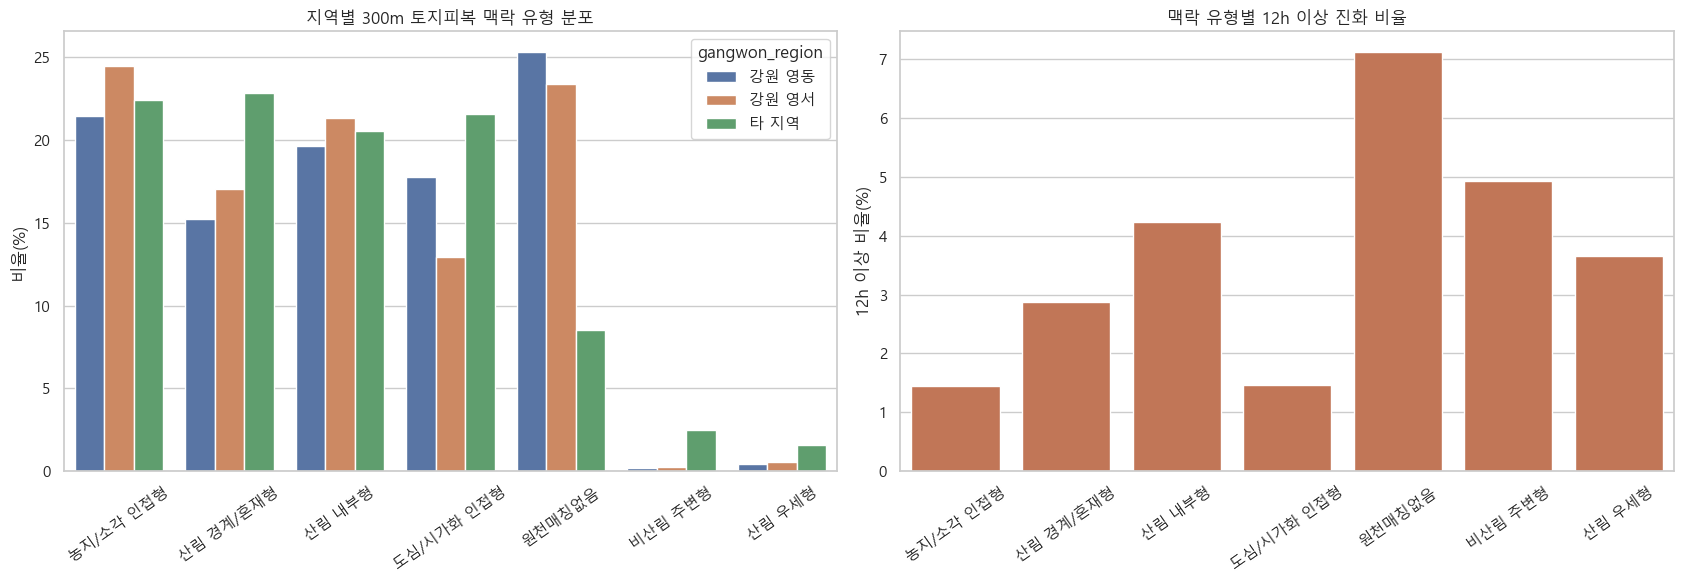

In [6]:
order = context_summary["landcover_context_type"].tolist()
plot_df = (
    df.groupby(["gangwon_region", "landcover_context_type"], observed=False)
    .size()
    .reset_index(name="N")
)
plot_df["비율(%)"] = plot_df["N"] / plot_df.groupby("gangwon_region")["N"].transform("sum") * 100

rate_df = context_summary.copy()
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.barplot(data=plot_df, x="landcover_context_type", y="비율(%)", hue="gangwon_region", order=order, ax=axes[0])
axes[0].set_title("지역별 300m 토지피복 맥락 유형 분포")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(data=rate_df, x="landcover_context_type", y="12h 이상 비율(%)", order=order, ax=axes[1], color="#d36f45")
axes[1].set_title("맥락 유형별 12h 이상 진화 비율")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
fig.savefig(TMP_PLOT_DIR / "01_context_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


### 3-1. 발생점·주변 맥락 해석 및 플롯 이미지 분석

발생점 자체가 `산림지역`인 사례가 가장 많지만, `농업지역`, `시가화건조지역`, `초지`, `나지` 위에서 시작한 산불도 적지 않다. 이 때문에 300m 반경 토지피복은 “산림 수종”보다 **발생 위치가 산림 내부인지, 농지/도심과 맞닿은 경계인지**를 먼저 구분하는 피처가 더 설명력이 있다.

맥락 유형별로는 `산림 내부형`, `산림 우세형`, `산림 경계/혼재형`이 진화 유효 표본과 12h 이상 비율에서 상대적으로 높다. 반대로 `도심/시가화 인접형`은 건수는 많지만 평균 피해면적과 10ha 이상 비율이 낮아, 빠른 신고·접근성 또는 비연속 연료 구조가 작용했을 가능성이 있다.


## 4. 산림까지의 거리와 산림 8방위 분포


In [7]:
forest_bins = [-0.1, 0, 30, 100, 300, 1e9]
forest_labels = ["발생점 포함", "0-30m", "30-100m", "100-300m", "300m내 산림 없음"]
df["forest_dist_band"] = pd.cut(
    pd.to_numeric(df["nearest_forest_dist_m"], errors="coerce").fillna(999999),
    bins=forest_bins,
    labels=forest_labels,
)
forest_dist_summary = summarize_group("forest_dist_band")
display(forest_dist_summary.round(4))

sector_order = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
direction_df = df[df["forest_dominant_direction"].isin(sector_order)].copy()
direction_summary = (
    direction_df.groupby("forest_dominant_direction")
    .apply(lambda g: pd.Series({
        "전체 N": len(g),
        "진화 유효 N": g["_suppression_valid"].sum(),
        "평균 진화시간(h)": g.loc[g["_suppression_valid"], "_suppression_hours"].mean(),
        "12h 이상 비율(%)": g.loc[g["_suppression_valid"], "_large_fire_12h"].mean() * 100,
        "평균 피해면적(ha)": g["_damage_ha"].mean(),
        "강원 비율(%)": g["is_gangwon"].mean() * 100,
    }), include_groups=False)
    .reindex(sector_order)
)
display(direction_summary.round(4))

yd_direction_summary = (
    df[(df["gangwon_region"].eq("강원 영동")) & (df["forest_dominant_direction"].isin(sector_order))]
    .groupby("forest_dominant_direction")
    .apply(lambda g: pd.Series({
        "전체 N": len(g),
        "진화 유효 N": g["_suppression_valid"].sum(),
        "평균 진화시간(h)": g.loc[g["_suppression_valid"], "_suppression_hours"].mean(),
        "12h 이상 비율(%)": g.loc[g["_suppression_valid"], "_large_fire_12h"].mean() * 100,
        "평균 피해면적(ha)": g["_damage_ha"].mean(),
    }), include_groups=False)
    .reindex(sector_order)
)
display(yd_direction_summary.round(4))


,forest_dist_band,전체 N,진화 유효 N,평균 진화시간(h),중앙 진화시간(h),12h 이상 비율(%),10ha 이상 비율(%),평균 피해면적(ha),강원 비율(%),산림 평균 비율,시가화 평균 비율,농업 평균 비율
0,발생점 포함,10963,5191,2.1144,1.1667,3.4675,0.9395,2.5911,14.5489,0.7669,0.0518,0.1056
1,0-30m,4107,591,1.8057,1.0000,2.7073,0.2191,1.2054,12.9778,0.4840,0.1112,0.2472
2,30-100m,3975,270,1.7864,1.0000,2.5926,0.1258,0.0814,16.7296,0.2731,0.2055,0.3341
4,300m내 산림 없음,3657,291,2.9872,1.5000,6.8729,0.3828,1.2062,28.2472,0.0000,0.5595,0.1496
3,100-300m,2334,96,1.6825,1.0333,2.0833,0.0000,0.0175,13.4105,0.1143,0.2947,0.3568


,전체 N,진화 유효 N,평균 진화시간(h),12h 이상 비율(%),평균 피해면적(ha),강원 비율(%)
forest_dominant_direction,,,,,,
N,2968.0,1075.0,2.2433,3.0698,2.5971,15.6334
NE,2233.0,571.0,1.7656,2.6270,0.7901,10.4792
E,4598.0,1131.0,2.0725,3.1830,0.4246,14.5716
SE,1784.0,405.0,1.7975,2.2222,0.6016,21.4126
S,2213.0,815.0,2.3186,4.5399,2.3076,19.0691
SW,1637.0,364.0,1.8346,3.2967,0.3782,12.8283
W,3941.0,1194.0,2.0625,3.2663,3.7222,12.2811
NW,2005.0,593.0,1.9814,4.0472,0.4126,11.9701


,전체 N,진화 유효 N,평균 진화시간(h),12h 이상 비율(%),평균 피해면적(ha)
forest_dominant_direction,,,,,
N,148.0,50.0,5.5103,10.0000,45.7107
NE,62.0,10.0,5.2117,20.0000,21.7616
E,248.0,26.0,2.8904,7.6923,0.7802
SE,215.0,3.0,9.7056,33.3333,0.3219
S,120.0,42.0,2.3591,4.7619,1.5918
SW,67.0,11.0,1.5727,0.0000,0.7104
W,202.0,40.0,2.3933,7.5000,66.3378
NW,137.0,17.0,0.9755,0.0000,0.0526


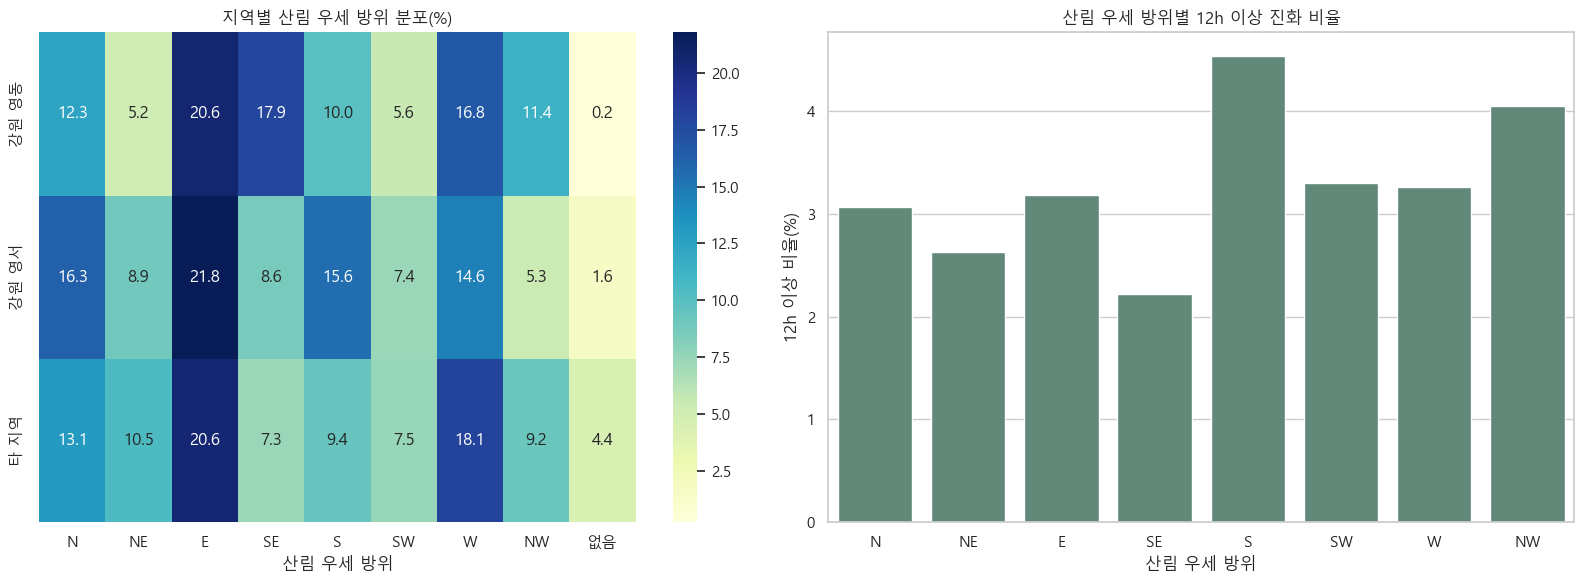

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
dir_share = (
    pd.crosstab(df["gangwon_region"], df["forest_dominant_direction"], normalize="index") * 100
).reindex(columns=sector_order + ["없음"], fill_value=0)
sns.heatmap(dir_share, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("지역별 산림 우세 방위 분포(%)")
axes[0].set_xlabel("산림 우세 방위")
axes[0].set_ylabel("")

sns.barplot(data=direction_summary.reset_index(), x="forest_dominant_direction", y="12h 이상 비율(%)", order=sector_order, ax=axes[1], color="#5a8f7b")
axes[1].set_title("산림 우세 방위별 12h 이상 진화 비율")
axes[1].set_xlabel("산림 우세 방위")
plt.tight_layout()
fig.savefig(TMP_PLOT_DIR / "02_forest_direction.png", dpi=160, bbox_inches="tight")
plt.show()


### 4-1. 산림 거리·방향 해석 및 플롯 이미지 분석

산불 발생점이 산림 폴리곤 안에 포함되는 경우가 가장 위험 신호가 강하다. 산림까지 거리가 30m 이상 멀어질수록 평균 피해와 12h 이상 비율이 급격히 낮아져, 단순 300m 반경 산림비율보다 **발생점과 산림의 접촉 여부**가 더 직접적인 피처가 될 수 있다.

산림 우세 방위는 전국 기준으로 어느 한 방향이 압도적이지 않지만, 강원 영동에서는 일부 방향에서 평균 피해면적이 크게 튄다. 다만 영동 방향별 표본은 작은 칸이 있으므로, 방위 단독 규칙보다 기존의 `사면방향 × 풍향 × 영동권` 상호작용과 결합하는 방식이 안전하다.


## 5. 발생원인명과 토지피복 맥락의 결합


In [9]:
cause_counts = df["cause_group"].value_counts().rename_axis("원인그룹").reset_index(name="N")
display(cause_counts)

cause_context = pd.crosstab(
    df["cause_group"],
    df["landcover_context_type"],
    normalize="index",
) * 100
display(cause_context.round(2))

cause_result = (
    df.groupby("cause_group")
    .apply(lambda g: pd.Series({
        "전체 N": len(g),
        "진화 유효 N": g["_suppression_valid"].sum(),
        "평균 진화시간(h)": g.loc[g["_suppression_valid"], "_suppression_hours"].mean(),
        "12h 이상 비율(%)": g.loc[g["_suppression_valid"], "_large_fire_12h"].mean() * 100,
        "평균 피해면적(ha)": g["_damage_ha"].mean(),
        "산림 평균 비율": g["raw_forest_ratio"].mean(),
        "시가화 평균 비율": g["raw_built_ratio"].mean(),
        "농업 평균 비율": g["raw_agri_ratio"].mean(),
    }), include_groups=False)
    .sort_values("전체 N", ascending=False)
)
display(cause_result.round(4))


,원인그룹,N
0,미상/미기록,18738
1,입산/산림활동,3011
2,소각/농업활동,1786
3,도로/담뱃불,581
4,기타,435
5,방화/불장난,279
6,공사/작업,95
7,주거/시설 비화,66
8,자연/낙뢰,45


landcover_context_type,농지/소각 인접형,도심/시가화 인접형,비산림 주변형,산림 경계/혼재형,산림 내부형,산림 우세형,원천매칭없음
cause_group,,,,,,,
공사/작업,10.53,2.11,5.26,32.63,43.16,4.21,2.11
기타,4.37,3.68,4.14,26.90,43.22,3.45,14.25
도로/담뱃불,6.88,12.05,2.58,38.21,32.53,3.79,3.96
미상/미기록,27.62,25.24,2.09,17.28,13.28,1.03,13.45
방화/불장난,5.73,23.66,1.43,40.86,25.09,2.15,1.08
소각/농업활동,12.77,3.70,2.35,45.30,31.08,2.18,2.63
입산/산림활동,4.75,5.75,1.59,29.59,51.91,2.42,3.99
자연/낙뢰,8.89,0.00,2.22,13.33,64.44,4.44,6.67
주거/시설 비화,10.61,4.55,1.52,34.85,40.91,0.00,7.58


,전체 N,진화 유효 N,평균 진화시간(h),12h 이상 비율(%),평균 피해면적(ha),산림 평균 비율,시가화 평균 비율,농업 평균 비율
cause_group,,,,,,,,
미상/미기록,18738.0,146.0,2.5090,2.7397,0.0031,0.4501,0.1623,0.2402
입산/산림활동,3011.0,3009.0,2.2080,3.3234,4.5263,0.7827,0.0562,0.0682
소각/농업활동,1786.0,1785.0,1.7436,3.0812,9.9790,0.6898,0.0479,0.1451
도로/담뱃불,581.0,579.0,1.6005,1.8998,4.6830,0.6772,0.1173,0.0858
기타,435.0,435.0,3.1023,7.3563,6.1518,0.7590,0.0480,0.0783
방화/불장난,279.0,279.0,1.8912,2.5090,2.5163,0.6260,0.1779,0.0784
공사/작업,95.0,95.0,2.7435,7.3684,3.6737,0.7503,0.0432,0.1133
주거/시설 비화,66.0,66.0,2.6437,6.0606,2.0742,0.7779,0.0446,0.1163
자연/낙뢰,45.0,45.0,4.3233,11.1111,0.8240,0.8387,0.0151,0.0648


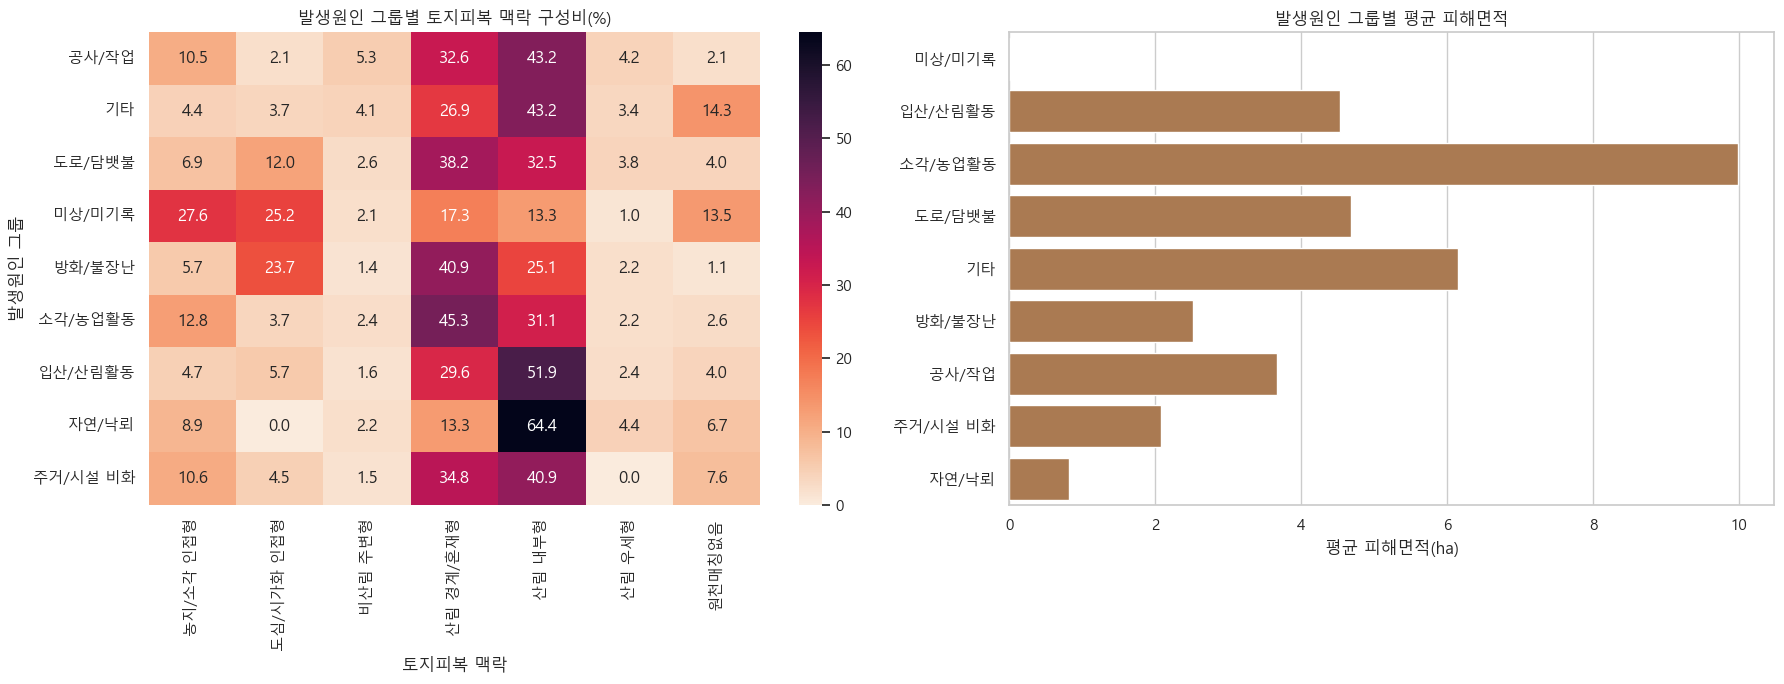

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cause_context, annot=True, fmt=".1f", cmap="rocket_r", ax=axes[0])
axes[0].set_title("발생원인 그룹별 토지피복 맥락 구성비(%)")
axes[0].set_xlabel("토지피복 맥락")
axes[0].set_ylabel("발생원인 그룹")

cause_result_plot = cause_result.reset_index()
sns.barplot(data=cause_result_plot, y="cause_group", x="평균 피해면적(ha)", ax=axes[1], color="#b97943")
axes[1].set_title("발생원인 그룹별 평균 피해면적")
axes[1].set_ylabel("")
plt.tight_layout()
fig.savefig(TMP_PLOT_DIR / "03_cause_context.png", dpi=160, bbox_inches="tight")
plt.show()


### 5-1. 발생원인·토지피복 결합 해석 및 플롯 이미지 분석

`소각/농업활동`은 이름만 보면 농지 중심이어야 할 것 같지만, 실제로는 `산림 경계/혼재형`과 `산림 내부형` 비율이 높다. 이는 소각 행위가 농지 내부에서 끝나는 문제가 아니라 산림 경계부로 확산되는 구조를 갖는다는 해석과 연결된다.

`입산/산림활동`과 `자연/낙뢰`는 산림 내부형 비율이 가장 높아 직관과 일치한다. `도로/담뱃불`과 `방화/불장난`은 도심/시가화 인접형 비율이 상대적으로 올라가므로, 도심·도로변 발화와 산림 경계 확산을 분리해 모델링할 필요가 있다.


## 6. 도심·농지·산림 경계와 접근성 보완 분석


In [11]:
access_summary = (
    df.groupby("landcover_context_type")
    .apply(lambda g: pd.Series({
        "전체 N": len(g),
        "소방서 평균거리(km)": g["nearest_station_dist_km"].mean(),
        "소방용수 평균거리(km)": g["nearest_water_dist_km"].mean(),
        "산불소화시설 평균거리(km)": g["nearest_facility_dist_km"].mean(),
        "임도 평균거리(km)": g["nearest_road_dist_km"].mean(),
        "등산로 평균거리(km)": g["nearest_trail_dist_km"].mean(),
        "시가화 최단거리(m)": pd.to_numeric(g["nearest_built_dist_m"], errors="coerce").mean(),
        "산림 최단거리(m)": pd.to_numeric(g["nearest_forest_dist_m"], errors="coerce").mean(),
        "원격제어 불가능(%)": g["nearest_facility_remote"].astype(str).eq("불가능").mean() * 100,
        "평균 진화시간(h)": g.loc[g["_suppression_valid"], "_suppression_hours"].mean(),
    }), include_groups=False)
    .sort_values("전체 N", ascending=False)
)
display(access_summary.round(4))

interface_cols = ["forest_built_interface", "forest_agri_interface", "low_forest_built_candidate", "forest_core_candidate"]
for col in interface_cols:
    df[col] = df[col].astype(str).str.lower().isin(["true", "1"])

interface_summary = []
for col in interface_cols:
    for flag, g in df.groupby(col):
        valid = g[g["_suppression_valid"]]
        interface_summary.append({
            "조건": col,
            "해당 여부": flag,
            "전체 N": len(g),
            "진화 유효 N": len(valid),
            "평균 진화시간(h)": valid["_suppression_hours"].mean(),
            "12h 이상 비율(%)": valid["_large_fire_12h"].mean() * 100,
            "10ha 이상 비율(%)": g["_large_damage_10ha"].mean() * 100,
            "평균 피해면적(ha)": g["_damage_ha"].mean(),
        })
interface_summary = pd.DataFrame(interface_summary)
display(interface_summary.round(4))


,전체 N,소방서 평균거리(km),소방용수 평균거리(km),산불소화시설 평균거리(km),임도 평균거리(km),등산로 평균거리(km),시가화 최단거리(m),산림 최단거리(m),원격제어 불가능(%),평균 진화시간(h)
landcover_context_type,,,,,,,,,,
농지/소각 인접형,5643.0,5.2229,0.7581,14.2391,8.9233,2.4469,69.7462,50.4719,70.2286,1.6130
산림 경계/혼재형,5451.0,5.4681,1.0287,13.3212,10.3905,2.1027,90.7111,5.2830,67.2537,1.8414
산림 내부형,5151.0,6.9828,1.7813,13.4099,8.1500,1.9314,164.2042,1.0261,69.4234,2.4153
도심/시가화 인접형,5125.0,3.0865,0.4702,12.5015,10.8075,1.8234,4.6382,73.1404,71.6683,1.2015
원천매칭없음,2786.0,22.3251,15.8681,23.6380,26.8791,19.3073,NaN,NaN,79.3611,3.0973
비산림 주변형,526.0,5.4904,1.0443,15.7820,13.3412,3.1413,46.9558,60.6364,62.3574,1.9616
산림 우세형,354.0,8.4312,1.6699,14.5934,10.8764,3.7529,113.3779,6.5394,63.5593,2.8265


,조건,해당 여부,전체 N,진화 유효 N,평균 진화시간(h),12h 이상 비율(%),10ha 이상 비율(%),평균 피해면적(ha)
0,forest_built_interface,False,18845,4964,2.2927,3.8678,0.6155,1.8447
1,forest_built_interface,True,6191,1475,1.4748,2.2373,0.2423,0.5441
2,forest_agri_interface,False,16434,4536,2.2134,3.6817,0.5537,0.9349
3,forest_agri_interface,True,8602,1903,1.8477,3.0478,0.4650,2.6467
4,low_forest_built_candidate,False,21402,6254,2.1260,3.5337,0.6074,1.7769
5,low_forest_built_candidate,True,3634,185,1.4061,2.1622,0.0275,0.0283
6,forest_core_candidate,False,19762,3703,1.8785,2.9706,0.3745,1.4602
7,forest_core_candidate,True,5274,2736,2.4122,4.2032,1.0808,1.7586


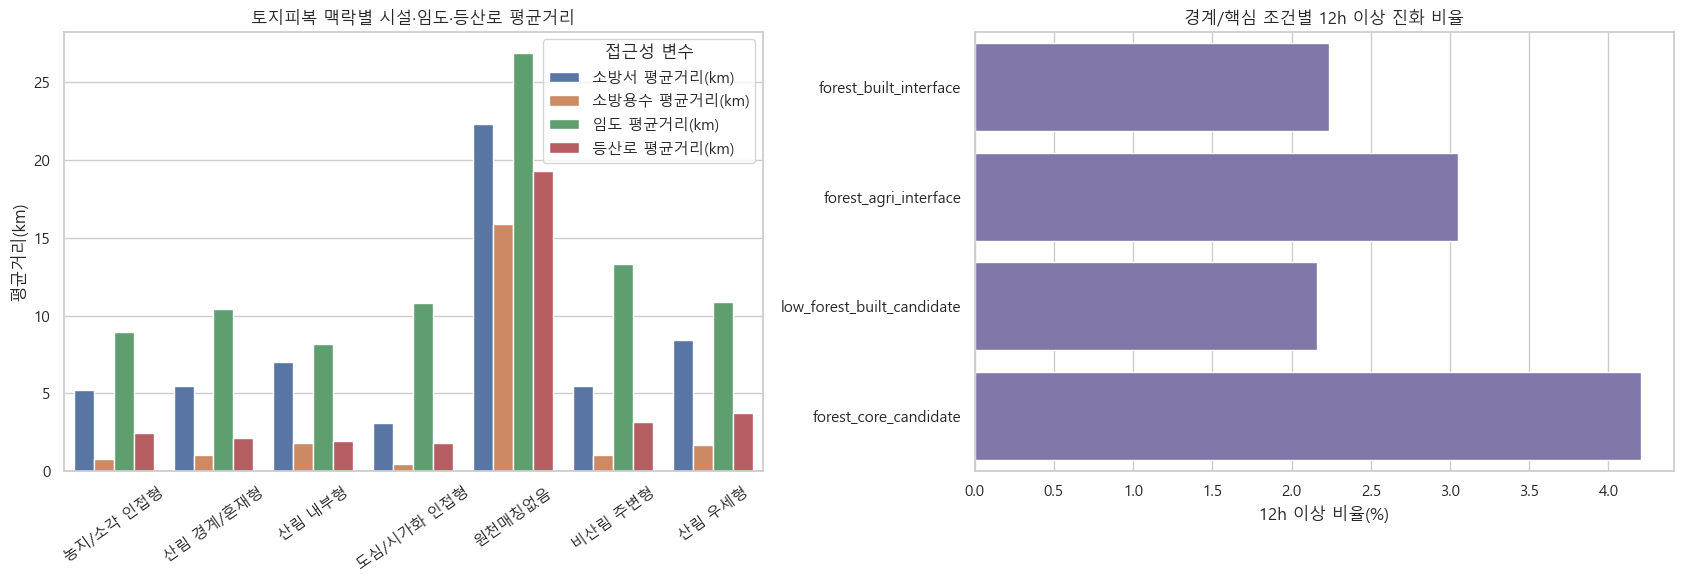

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
access_plot = access_summary.reset_index().melt(
    id_vars="landcover_context_type",
    value_vars=["소방서 평균거리(km)", "소방용수 평균거리(km)", "임도 평균거리(km)", "등산로 평균거리(km)"],
    var_name="접근성 변수",
    value_name="평균거리(km)",
)
sns.barplot(data=access_plot, x="landcover_context_type", y="평균거리(km)", hue="접근성 변수", ax=axes[0])
axes[0].set_title("토지피복 맥락별 시설·임도·등산로 평균거리")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)

interface_plot = interface_summary[interface_summary["해당 여부"]].copy()
sns.barplot(data=interface_plot, y="조건", x="12h 이상 비율(%)", ax=axes[1], color="#7c6fb0")
axes[1].set_title("경계/핵심 조건별 12h 이상 진화 비율")
axes[1].set_ylabel("")
plt.tight_layout()
fig.savefig(TMP_PLOT_DIR / "04_access_interface.png", dpi=160, bbox_inches="tight")
plt.show()


### 6-1. 접근성 보완 해석 및 플롯 이미지 분석

기존 `nearest_road_dist_km`는 일반 도로가 아니라 임도망도 기준이므로, “도심 또는 도로 접근성”으로 바로 해석하면 안 된다. 이번 분석에서는 시가화건조지역 최단거리와 소방서·소방용수·임도·등산로 거리를 함께 보되, 일반 도로망 데이터가 없다는 한계를 명시한다.

플롯상 원천매칭없음은 시설·임도·등산로 평균거리가 매우 길어 별도 품질/공간 범위 이슈로 분리해야 한다. 해석 가능한 유형 중에서는 도심/시가화 인접형의 소방서·소방용수 접근이 상대적으로 유리하고 평균 피해가 작다. 반대로 산림 내부형·산림 우세형은 산림과 직접 접촉하면서 연료 연속성이 커져 진화 지연률이 높다. 오른쪽 막대에서는 
orest_core_candidate가 가장 높고 
orest_agri_interface도 높아, 산림 내부성과 농지-산림 경계 조건을 발생원인, 계절, 강풍 조건과의 상호작용으로 모델링하는 것이 타당하다.


## 7. 번지의 `산` 여부와 실제 토지피복의 불일치


In [13]:
parcel_cross = pd.crosstab(df["is_mountain_parcel"], df["point_landcover_major"], normalize="index") * 100
display(parcel_cross.round(2))

parcel_summary = (
    df.groupby("is_mountain_parcel")
    .apply(lambda g: pd.Series({
        "전체 N": len(g),
        "진화 유효 N": g["_suppression_valid"].sum(),
        "산림 발생점 비율(%)": g["point_landcover_major"].eq("산림지역").mean() * 100,
        "시가화 발생점 비율(%)": g["point_landcover_major"].eq("시가화건조지역").mean() * 100,
        "농업 발생점 비율(%)": g["point_landcover_major"].eq("농업지역").mean() * 100,
        "평균 진화시간(h)": g.loc[g["_suppression_valid"], "_suppression_hours"].mean(),
        "12h 이상 비율(%)": g.loc[g["_suppression_valid"], "_large_fire_12h"].mean() * 100,
        "평균 피해면적(ha)": g["_damage_ha"].mean(),
    }), include_groups=False)
)
display(parcel_summary.round(4))


point_landcover_major,나지,농업지역,미확인,산림지역,수역,습지,시가화건조지역,원천매칭없음,초지
is_mountain_parcel,,,,,,,,,
False,4.79,24.60,0.44,20.89,0.69,0.64,26.26,13.73,7.97
True,1.95,6.58,0.45,72.81,0.53,0.09,3.59,7.83,6.17


,전체 N,진화 유효 N,산림 발생점 비율(%),시가화 발생점 비율(%),농업 발생점 비율(%),평균 진화시간(h),12h 이상 비율(%),평균 피해면적(ha)
is_mountain_parcel,,,,,,,,
False,13995.0,88.0,20.8932,26.2594,24.6016,2.2445,5.6818,0.0059
True,11041.0,6351.0,72.8104,3.5866,6.5845,2.1034,3.4640,3.4462


### 7-1. 주소 기반 산지 판정의 한계

`발생지역번지`에 `산`이 들어가는지는 산지 여부를 가늠하는 유용한 보조 신호지만, 실제 발생점 피복과 완전히 일치하지 않는다. 따라서 모델링에서는 주소 문자열만으로 산림 내부/도심 인접을 판단하지 말고, 원천 토지피복 기반의 `point_landcover_major`, `nearest_forest_dist_m`, `landcover_context_type`을 함께 써야 한다.


## 8. 보완·심화 분석 결론 및 모델링 후보


In [14]:
model_feature_candidates = pd.DataFrame([
    {"피처": "point_landcover_major", "의미": "산불 발생점 자체의 토지피복", "활용": "산림 내부/농지/도심 발화 구분"},
    {"피처": "landcover_context_type", "의미": "300m 주변 피복 조합 유형", "활용": "산림 내부형, 산림 경계/혼재형, 도심/시가화 인접형 구분"},
    {"피처": "nearest_forest_dist_m", "의미": "발생점에서 산림까지 최단거리", "활용": "산림 접촉 여부 및 경계 확산 가능성"},
    {"피처": "forest_dominant_direction", "의미": "300m 내 산림 면적이 가장 큰 8방위", "활용": "사면방향·풍향과 결합한 확산 방향성"},
    {"피처": "forest_direction_entropy", "의미": "산림 면적의 방향 분산도", "활용": "한쪽 경계형 vs 산림 포위형 구분"},
    {"피처": "forest_built_interface", "의미": "산림과 시가화지역이 함께 존재", "활용": "도심-산림 접경 위험"},
    {"피처": "forest_agri_interface", "의미": "산림과 농업지역이 함께 존재", "활용": "소각·농업활동 확산 위험"},
    {"피처": "cause_group", "의미": "발생원인명 패턴 그룹", "활용": "토지피복 맥락과 원인별 위험 프로파일"},
    {"피처": "sg05_area_ratio", "의미": "세분류 토지피복 자료 비율", "활용": "수종 세분류 피처 신뢰도 보정"},
])
display(model_feature_candidates)


,피처,의미,활용
0,point_landcover_major,산불 발생점 자체의 토지피복,산림 내부/농지/도심 발화 구분
1,landcover_context_type,300m 주변 피복 조합 유형,"산림 내부형, 산림 경계/혼재형, 도심/시가화 인접형 구분"
2,nearest_forest_dist_m,발생점에서 산림까지 최단거리,산림 접촉 여부 및 경계 확산 가능성
3,forest_dominant_direction,300m 내 산림 면적이 가장 큰 8방위,사면방향·풍향과 결합한 확산 방향성
4,forest_direction_entropy,산림 면적의 방향 분산도,한쪽 경계형 vs 산림 포위형 구분
5,forest_built_interface,산림과 시가화지역이 함께 존재,도심-산림 접경 위험
6,forest_agri_interface,산림과 농업지역이 함께 존재,소각·농업활동 확산 위험
7,cause_group,발생원인명 패턴 그룹,토지피복 맥락과 원인별 위험 프로파일
8,sg05_area_ratio,세분류 토지피복 자료 비율,수종 세분류 피처 신뢰도 보정


### 8-1. 최종 정리

이번 심화 분석에서 가장 중요한 보완점은 다음과 같다.

1. 기존 캐시의 `산림지역_ratio=0` 중 일부는 실제 비산림 산불이 아니라 원천 토지피복 매칭 없음이었다. 모델링 전 원천 매칭 없음 플래그를 반드시 분리해야 한다.
2. 토지피복도는 수종 세분류보다 발생점 피복, 산림 최단거리, 산림/도심/농지 경계 구조가 더 우선이다.
3. 도심 또는 도심 근처 산불은 실제로 존재하며, `도심/시가화 인접형`은 피해가 작게 제어되는 경향이 있다. 다만 일반 도로망 데이터가 없어 도로 접근성은 아직 직접 검증하지 못했다.
4. 소각·농업활동 원인은 농지 내부보다 산림 경계/혼재형 비율이 높아, 농지-산림 경계 확산 피처가 필요하다.
5. 산림 방향성은 단독 효과보다 풍향, 사면방향, 영동권 여부와 결합해 확산 위험을 설명하는 상호작용 후보로 남기는 것이 안전하다.

추가로 필요한 원천 데이터는 일반 도로망 또는 도로 중심선 데이터다. 현재 `nearest_road_dist_km`는 임도망도 기준이라 “차량 접근 가능한 일반 도로”를 대표하지 않는다.
